# 01 - Exploratory Data Analysis & Preprocessing

**Project:** Used Car Price Prediction  
**Dataset:** `../data/raw/used_cars/train.csv`  
**Goal:** Understand the data, clean it, engineer features, and prepare train/test splits for modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

---
## Section 1 – Load & Inspect Data

We start by loading the raw CSV into a pandas DataFrame.  
Initial inspection tells us the shape, column types, and extent of missing/duplicate data — all of which guide the cleaning decisions in Section 2.

In [2]:
# Load the dataset
df = pd.read_csv('../data/raw/used_cars/train.csv', index_col=0)

print('Shape:', df.shape)
print('\nColumn dtypes:')
print(df.dtypes)
print('\nFirst 5 rows:')
df.head()

Shape: (5847, 13)

Column dtypes:
Name                  object
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage               object
Engine                object
Power                 object
Seats                float64
New_Price             object
Price                float64
dtype: object

First 5 rows:


,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50


Missing values per column:
New_Price    5032
Seats          38
Engine         36
Power          36
Mileage         2
dtype: int64


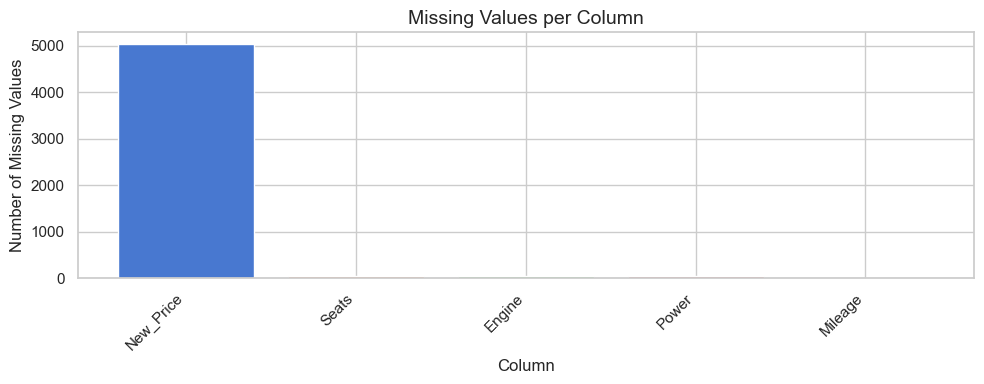

In [3]:
# Count missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Missing values per column:')
print(missing)

# Visualise missing values as a bar chart
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(missing.index, missing.values, color=sns.color_palette('muted'))
ax.set_title('Missing Values per Column', fontsize=14)
ax.set_xlabel('Column')
ax.set_ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [4]:
# Count and remove exact duplicate rows
n_duplicates = df.duplicated().sum()
print(f'Duplicate rows found: {n_duplicates}')

rows_before = len(df)
df = df.drop_duplicates()
rows_after = len(df)

print(f'Total rows before cleaning: {rows_before}')
print(f'Total rows after cleaning:  {rows_after}')

Duplicate rows found: 0
Total rows before cleaning: 5847
Total rows after cleaning:  5847


---
## Section 2 – Data Cleaning

Raw data contains:
- **Mixed-type string columns** — `Mileage`, `Engine`, and `Power` store numeric values with units (e.g. `"19.67 kmpl"`, `"1582 CC"`, `"126.2 bhp"`).  We strip the units and cast to `float`.
- **Columns with excessive missing data** — `New_Price` is missing for ~86 % of rows (5032 / 5847), making imputation unreliable; we drop it entirely.
- **Rows with essential features missing** — `Mileage`, `Engine`, `Power`, `Seats` are core predictors; rows missing any of them are removed.
- **Price outliers** — extreme values (< 1 or > 80 Lakh) likely represent data-entry errors and are filtered out.

In [5]:
# Drop New_Price — too many missing values (5032 / 5847)
rows_before_drop = len(df)
df = df.drop(columns=['New_Price'])
print(f'Dropped New_Price column. Rows unchanged: {len(df)}')

Dropped New_Price column. Rows unchanged: 5847


In [6]:
# Remove rows missing any of the essential numeric columns
essential_cols = ['Mileage', 'Engine', 'Power', 'Seats']
rows_before_na = len(df)
df = df.dropna(subset=essential_cols)
rows_after_na = len(df)
print(f'Rows before removing rows with missing Mileage/Engine/Power/Seats: {rows_before_na}')
print(f'Rows after:  {rows_after_na}')

Rows before removing rows with missing Mileage/Engine/Power/Seats: 5847
Rows after:  5807


In [7]:
# Clean Mileage: remove units (kmpl / km/kg) and convert to float
df['Mileage'] = df['Mileage'].str.extract(r'([\d.]+)').astype(float)

# Clean Engine: remove 'CC' and convert to float
df['Engine'] = df['Engine'].str.extract(r'([\d.]+)').astype(float)

# Clean Power: remove 'bhp' and convert to float
df['Power'] = df['Power'].str.replace('null bhp', '', regex=False).str.extract(r'([\d.]+)').astype(float)

print('Dtypes after cleaning:')
print(df[['Mileage', 'Engine', 'Power']].dtypes)
print('\nSample:')
df[['Mileage', 'Engine', 'Power']].head()

Dtypes after cleaning:
Mileage    float64
Engine     float64
Power      float64
dtype: object

Sample:


,Mileage,Engine,Power
1,19.67,1582.0,126.20
2,13.00,1199.0,88.70
3,20.77,1248.0,88.76
4,15.20,1968.0,140.80
6,23.08,1461.0,63.10


In [8]:
# Remove outliers from Price: keep rows where 1 <= Price <= 80
rows_before_outlier = len(df)
df = df.loc[(df['Price'] >= 1) & (df['Price'] <= 80)]
rows_after_outlier = len(df)
print(f'Rows before Price outlier removal: {rows_before_outlier}')
print(f'Rows after Price outlier removal:  {rows_after_outlier}')

# Also drop any rows where Power became NaN after stripping 'null bhp'
rows_before_power = len(df)
df = df.dropna(subset=['Power'])
print(f'Rows after dropping NaN Power:     {len(df)}')

Rows before Price outlier removal: 5807
Rows after Price outlier removal:  5737
Rows after dropping NaN Power:     5737


In [9]:
# Final dataset size
print(f'Final dataset shape: {df.shape}')
df.info()

Final dataset shape: (5737, 12)
<class 'pandas.core.frame.DataFrame'>
Index: 5737 entries, 1 to 6018
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               5737 non-null   object 
 1   Location           5737 non-null   object 
 2   Year               5737 non-null   int64  
 3   Kilometers_Driven  5737 non-null   int64  
 4   Fuel_Type          5737 non-null   object 
 5   Transmission       5737 non-null   object 
 6   Owner_Type         5737 non-null   object 
 7   Mileage            5737 non-null   float64
 8   Engine             5737 non-null   float64
 9   Power              5737 non-null   float64
 10  Seats              5737 non-null   float64
 11  Price              5737 non-null   float64
dtypes: float64(5), int64(2), object(5)
memory usage: 582.7+ KB


---
## Section 3 – Exploratory Data Analysis (EDA)

Before building any model, we need to understand the distributions and relationships in the data.  
Key questions:  
- How is the target variable `Price` distributed?  
- Which features appear to correlate most strongly with price?  
- Are there notable differences across categorical groups (Fuel_Type, Transmission)?  

All charts include titles and axis labels for readability.

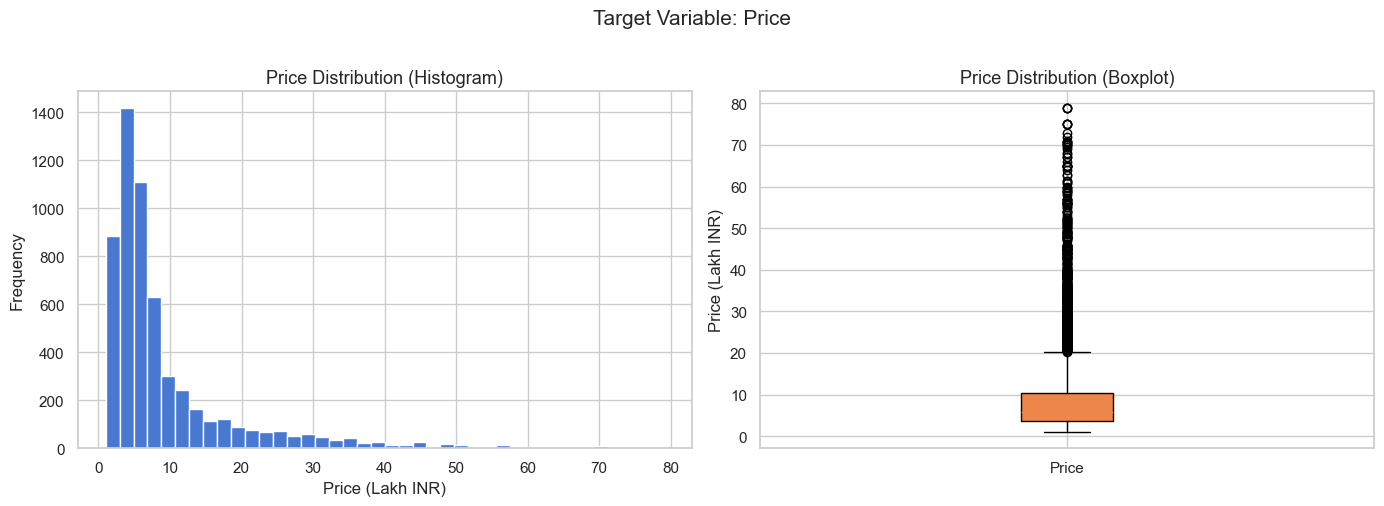

count    5737.000000
mean        9.622510
std        10.671741
min         1.000000
25%         3.650000
50%         5.800000
75%        10.300000
max        79.000000
Name: Price, dtype: float64


In [10]:
# Distribution of target variable: Price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Price'], bins=40, color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_title('Price Distribution (Histogram)', fontsize=13)
axes[0].set_xlabel('Price (Lakh INR)')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(df['Price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=sns.color_palette('muted')[1]))
axes[1].set_title('Price Distribution (Boxplot)', fontsize=13)
axes[1].set_ylabel('Price (Lakh INR)')
axes[1].set_xticklabels(['Price'])

plt.suptitle('Target Variable: Price', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print(df['Price'].describe())

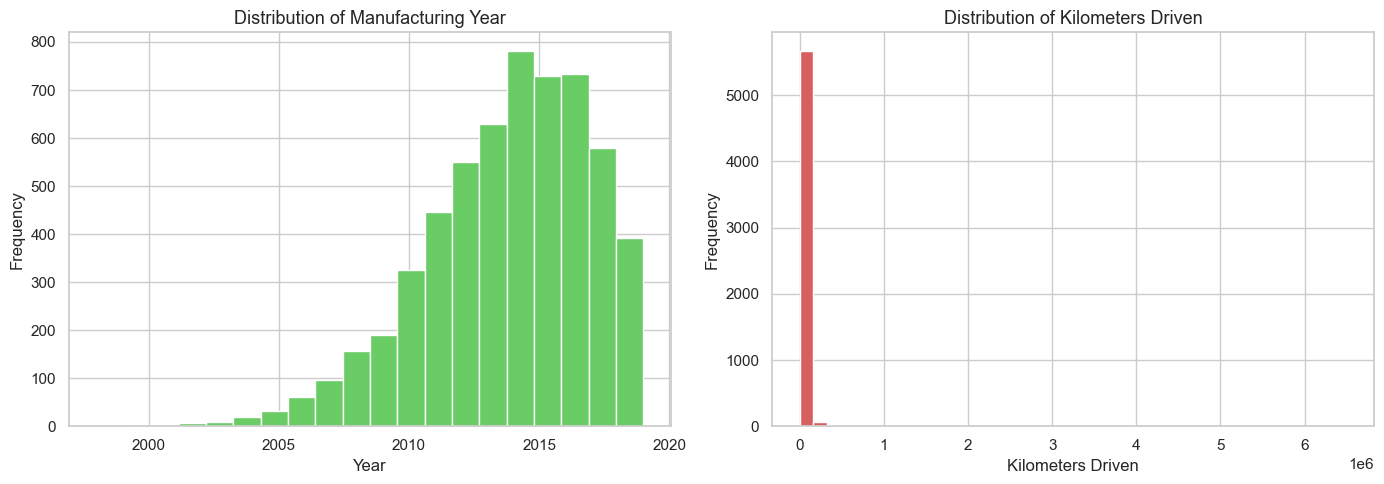

In [11]:
# Distribution of Year and Kilometers_Driven
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Year'], bins=20, color=sns.color_palette('muted')[2], edgecolor='white')
axes[0].set_title('Distribution of Manufacturing Year', fontsize=13)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Kilometers_Driven'], bins=40, color=sns.color_palette('muted')[3], edgecolor='white')
axes[1].set_title('Distribution of Kilometers Driven', fontsize=13)
axes[1].set_xlabel('Kilometers Driven')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

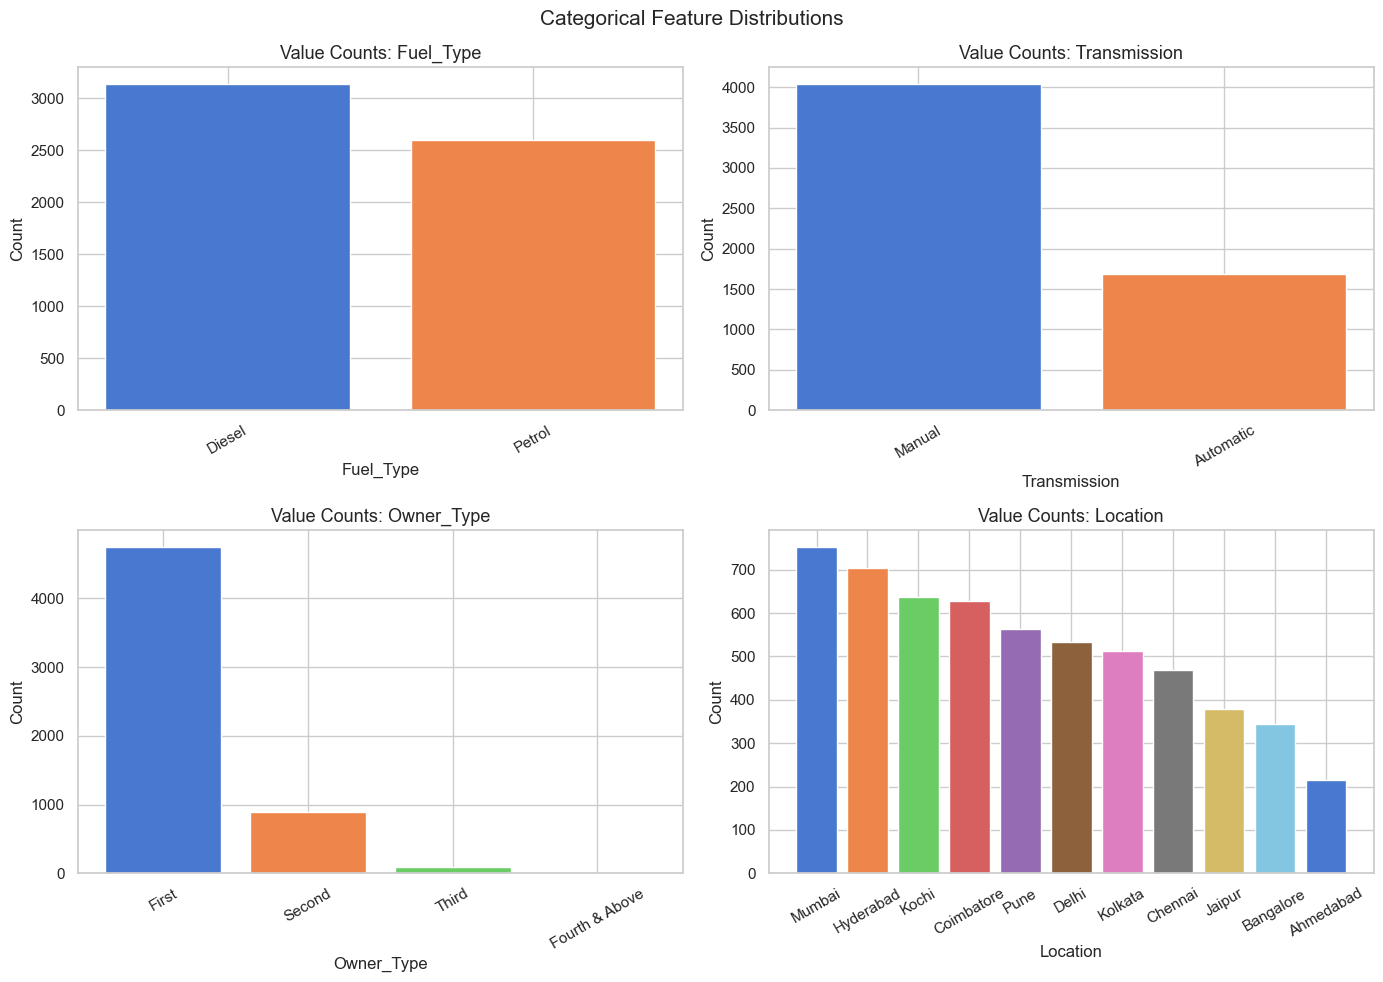

In [12]:
# Value counts bar charts for categorical columns
cat_cols = ['Fuel_Type', 'Transmission', 'Owner_Type', 'Location']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=sns.color_palette('muted', len(counts)))
    axes[i].set_title(f'Value Counts: {col}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Feature Distributions', fontsize=15)
plt.tight_layout()
plt.show()

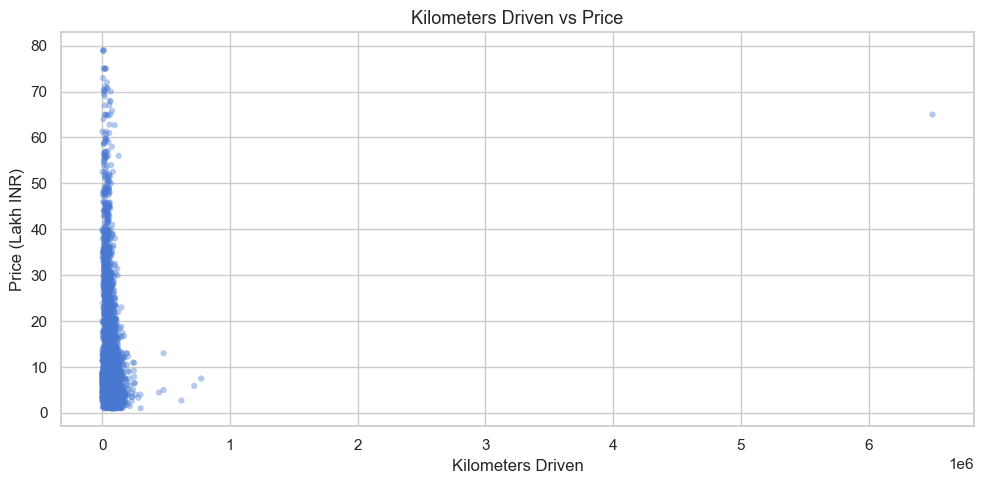

In [13]:
# Scatter plot: Kilometers_Driven vs Price
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df['Kilometers_Driven'], df['Price'], alpha=0.4,
           color=sns.color_palette('muted')[0], edgecolors='none', s=20)
ax.set_title('Kilometers Driven vs Price', fontsize=13)
ax.set_xlabel('Kilometers Driven')
ax.set_ylabel('Price (Lakh INR)')
plt.tight_layout()
plt.show()

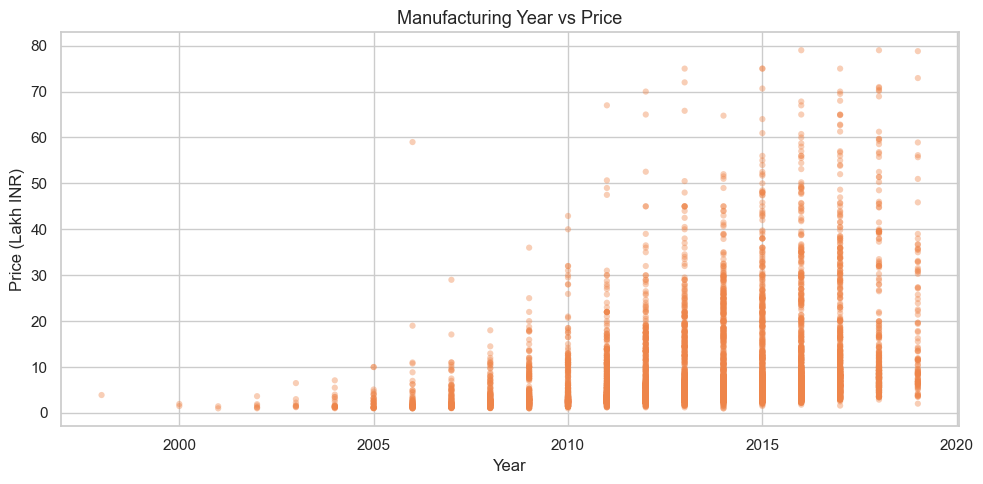

In [14]:
# Scatter plot: Year vs Price
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df['Year'], df['Price'], alpha=0.4,
           color=sns.color_palette('muted')[1], edgecolors='none', s=20)
ax.set_title('Manufacturing Year vs Price', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Price (Lakh INR)')
plt.tight_layout()
plt.show()

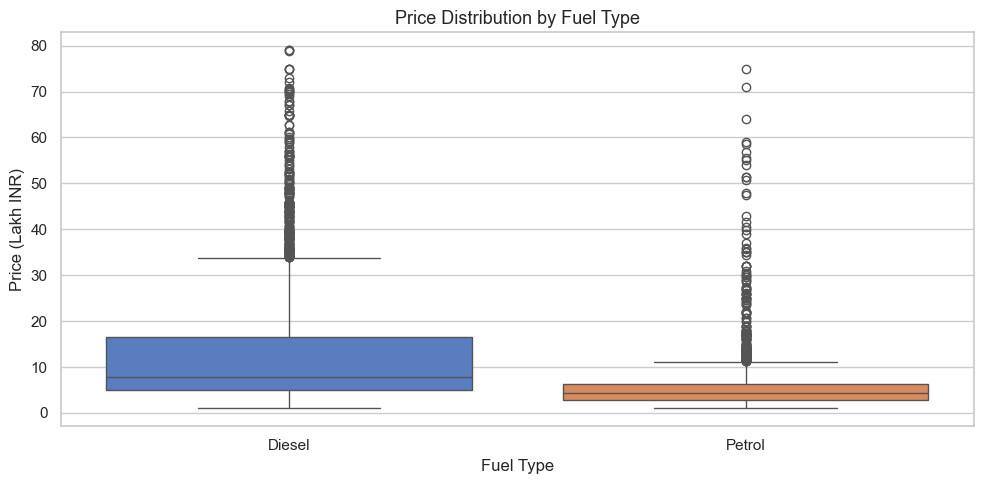

In [15]:
# Boxplot: Price by Fuel_Type
fig, ax = plt.subplots(figsize=(10, 5))
fuel_order = df.groupby('Fuel_Type')['Price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Fuel_Type', y='Price', order=fuel_order,
            palette='muted', ax=ax)
ax.set_title('Price Distribution by Fuel Type', fontsize=13)
ax.set_xlabel('Fuel Type')
ax.set_ylabel('Price (Lakh INR)')
plt.tight_layout()
plt.show()

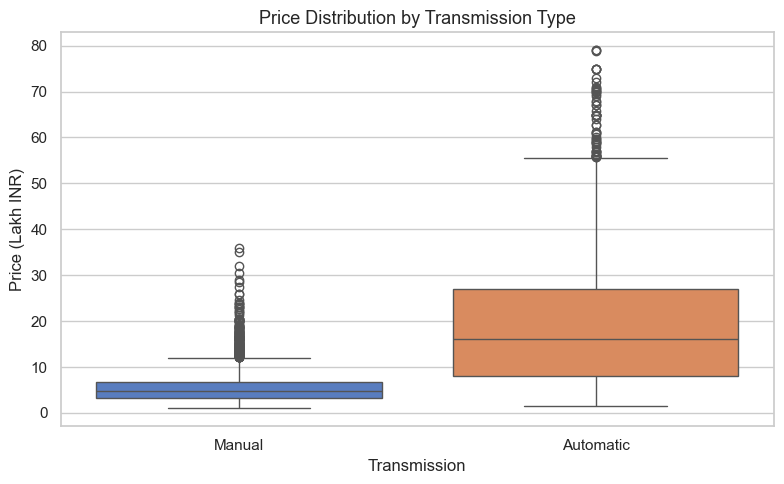

In [16]:
# Boxplot: Price by Transmission
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='Transmission', y='Price', palette='muted', ax=ax)
ax.set_title('Price Distribution by Transmission Type', fontsize=13)
ax.set_xlabel('Transmission')
ax.set_ylabel('Price (Lakh INR)')
plt.tight_layout()
plt.show()

### EDA Key Findings

1. **Price is right-skewed** — most cars are priced between 3–15 Lakh INR, but a long tail extends toward 80 Lakh, indicating a small luxury-car segment that may need special treatment in modelling.
2. **Newer cars command higher prices** — the Year vs Price scatter shows a clear upward trend: cars manufactured after 2013 cluster at higher price points.
3. **Low mileage ≠ high price unconditionally** — the Kilometers_Driven scatter is noisy, but cars with very high mileage (> 300,000 km) are almost exclusively low-priced, confirming heavy use degrades value.
4. **Automatic transmission cars are significantly more expensive** — the Transmission boxplot shows the median price for Automatic cars is roughly twice that of Manual, reflecting both luxury positioning and a higher demand premium.
5. **Diesel dominates the mid-range; Electric/LPG are rare** — Diesel cars form the largest group and span the widest price range, while CNG/LPG vehicles cluster at the low end. This class imbalance means tree-based models or stratified sampling may be needed.

---
## Section 4 – Feature Engineering

Raw columns are not yet model-ready:  
- **`Name`** contains the full car name; we extract only the **Brand** (first word) to reduce noise while retaining manufacturer-level information.  
- **`Year`** is an absolute year; converting it to **`Car_Age`** (2024 – Year) makes it directly interpretable and keeps the feature scale consistent.  
- **Categorical encoding** — we use two strategies:
  - *One-Hot Encoding* for `Fuel_Type`, `Transmission`, `Owner_Type`: these are **nominal** categories with no meaningful ordering, so we must not imply one. One-hot creates a binary column per category.
  - *Ordinal (Label) Encoding* for `Brand`: with 30 + distinct brands, one-hot would add too many sparse columns. Ordinal encoding maps each brand to an integer, keeping dimensionality manageable for tree-based models.  
- **MinMax normalisation** scales all numeric features to [0, 1], preventing high-magnitude features (e.g. `Engine` in CC) from dominating distance-based or gradient-based algorithms.

In [17]:
# Extract Brand as the first word of the Name column
df['Brand'] = df['Name'].str.split().str[0]
print(f'Unique brands: {df["Brand"].nunique()}')
print(df['Brand'].value_counts().head(10))

Unique brands: 29
Brand
Maruti           1092
Hyundai          1040
Honda             599
Toyota            393
Volkswagen        314
Mercedes-Benz     314
Ford              291
Mahindra          268
BMW               259
Audi              235
Name: count, dtype: int64


In [18]:
# Create Car_Age feature: 2024 - Year
df['Car_Age'] = 2024 - df['Year']
print('Car_Age sample:')
df[['Year', 'Car_Age']].head()

Car_Age sample:


,Year,Car_Age
1,2015,9
2,2011,13
3,2012,12
4,2013,11
6,2013,11


In [19]:
# One-Hot Encoding for nominal categorical columns
# We use pd.get_dummies instead of sklearn's OneHotEncoder for simplicity with DataFrames.
# drop_first=False keeps all levels — we want full interpretability for the course.
ohe_cols = ['Fuel_Type', 'Transmission', 'Owner_Type']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=False)
print('Columns after One-Hot Encoding:', df.shape[1])
print([c for c in df.columns if any(c.startswith(p) for p in ohe_cols)])

Columns after One-Hot Encoding: 19
['Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Transmission_Automatic', 'Transmission_Manual', 'Owner_Type_First', 'Owner_Type_Fourth & Above', 'Owner_Type_Second', 'Owner_Type_Third']


In [20]:
# Ordinal (Label) Encoding for Brand
# With 30+ unique brands, one-hot would create too many sparse columns.
le = LabelEncoder()
df['Brand'] = le.fit_transform(df['Brand'])
print('Brand encoded. Unique integer codes:', df['Brand'].nunique())

Brand encoded. Unique integer codes: 29


In [21]:
# Drop columns no longer needed after feature engineering
df = df.drop(columns=['Name', 'Year', 'Location'])
print('Shape after dropping Name, Year, Location:', df.shape)

Shape after dropping Name, Year, Location: (5737, 16)


In [22]:
# MinMax normalisation of numeric features
numeric_cols = ['Kilometers_Driven', 'Engine', 'Power', 'Mileage', 'Car_Age']

scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print('Numeric features scaled to [0, 1]:')
df[numeric_cols].describe().round(3)

Numeric features scaled to [0, 1]:


,Kilometers_Driven,Engine,Power,Mileage,Car_Age
count,5737.000,5737.000,5737.000,5737.000,5737.000
mean,0.009,0.188,0.154,0.642,0.259
std,0.014,0.111,0.102,0.151,0.145
min,0.000,0.000,0.000,0.000,0.000
25%,0.005,0.107,0.086,0.537,0.143
50%,0.008,0.162,0.124,0.643,0.238
75%,0.011,0.254,0.204,0.743,0.333
max,1.000,1.000,1.000,1.000,1.000


---
## Section 5 – Train/Test Split

We hold out 20 % of the data as an unseen test set.  
`random_state=42` ensures the split is reproducible across runs and team members.  
The remaining 80 % will be used for model training and cross-validation.

In [23]:
# Separate features X from target y
X = df.drop(columns=['Price'])
y = df['Price']

print('Feature matrix X shape:', X.shape)
print('Target vector y shape: ', y.shape)

Feature matrix X shape: (5737, 15)
Target vector y shape:  (5737,)


In [24]:
# Train/test split — 80 % train, 20 % test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape: ', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape: ', y_test.shape)

X_train shape: (4589, 15)
X_test shape:  (1148, 15)
y_train shape: (4589,)
y_test shape:  (1148,)


---
## Section 6 – Save Processed Data

We persist two artefacts for downstream notebooks:  
1. **`used_cars_clean.csv`** — the fully cleaned and encoded DataFrame (all rows, including both train and test).  The train/test split in Section 5 is re-applied in the modelling notebook for consistency.
2. **`feature_columns.json`** — the ordered list of feature column names so the modelling notebook can reconstruct `X` without re-running this notebook.

In [25]:
# Save cleaned and encoded dataframe
output_csv = '../data/processed/used_cars_clean.csv'
df.to_csv(output_csv, index=False)
print(f'Saved processed data to {output_csv}  ({df.shape[0]} rows, {df.shape[1]} cols)')

Saved processed data to ../data/processed/used_cars_clean.csv  (5737 rows, 16 cols)


In [26]:
# Save feature column names (all columns except Price)
feature_columns = list(X.columns)
output_json = '../data/processed/feature_columns.json'

with open(output_json, 'w') as f:
    json.dump(feature_columns, f, indent=2)

print(f'Saved {len(feature_columns)} feature column names to {output_json}')
print('Features:', feature_columns)

Saved 15 feature column names to ../data/processed/feature_columns.json
Features: ['Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Brand', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Transmission_Automatic', 'Transmission_Manual', 'Owner_Type_First', 'Owner_Type_Fourth & Above', 'Owner_Type_Second', 'Owner_Type_Third']
